In [50]:
import numpy as np

**Module** is an abstract class which defines fundamental methods necessary for a training a neural network. You do not need to change anything here, just read the comments.

In [51]:
class Module(object):
    """
    Basically, you can think of a module as of a something (black box)
    which can process `input` data and produce `ouput` data.
    This is like applying a function which is called `forward`:

        output = module.forward(input)

    The module should be able to perform a backward pass: to differentiate the `forward` function.
    More, it should be able to differentiate it if is a part of chain (chain rule).
    The latter implies there is a gradient from previous step of a chain rule.

        gradInput = module.backward(input, gradOutput)
    """
    def __init__ (self):
        self.output = None
        self.gradInput = None
        self.training = True

    def forward(self, input):
        """
        Takes an input object, and computes the corresponding output of the module.
        """
        return self.updateOutput(input)

    def backward(self,input, gradOutput):
        """
        Performs a backpropagation step through the module, with respect to the given input.

        This includes
         - computing a gradient w.r.t. `input` (is needed for further backprop),
         - computing a gradient w.r.t. parameters (to update parameters while optimizing).
        """
        self.updateGradInput(input, gradOutput)
        self.accGradParameters(input, gradOutput)
        return self.gradInput


    def updateOutput(self, input):
        """
        Computes the output using the current parameter set of the class and input.
        This function returns the result which is stored in the `output` field.

        Make sure to both store the data in `output` field and return it.
        """

        # The easiest case:

        # self.output = input
        # return self.output

        pass

    def updateGradInput(self, input, gradOutput):
        """
        Computing the gradient of the module with respect to its own input.
        This is returned in `gradInput`. Also, the `gradInput` state variable is updated accordingly.

        The shape of `gradInput` is always the same as the shape of `input`.

        Make sure to both store the gradients in `gradInput` field and return it.
        """

        # The easiest case:

        # self.gradInput = gradOutput
        # return self.gradInput

        pass

    def accGradParameters(self, input, gradOutput):
        """
        Computing the gradient of the module with respect to its own parameters.
        No need to override if module has no parameters (e.g. ReLU).
        """
        pass

    def zeroGradParameters(self):
        """
        Zeroes `gradParams` variable if the module has params.
        """
        pass

    def getParameters(self):
        """
        Returns a list with its parameters.
        If the module does not have parameters return empty list.
        """
        return []

    def getGradParameters(self):
        """
        Returns a list with gradients with respect to its parameters.
        If the module does not have parameters return empty list.
        """
        return []

    def train(self):
        """
        Sets training mode for the module.
        Training and testing behaviour differs for Dropout, BatchNorm.
        """
        self.training = True

    def evaluate(self):
        """
        Sets evaluation mode for the module.
        Training and testing behaviour differs for Dropout, BatchNorm.
        """
        self.training = False

    def __repr__(self):
        """
        Pretty printing. Should be overrided in every module if you want
        to have readable description.
        """
        return "Module"

# Sequential container

**Define** a forward and backward pass procedures.

In [52]:
class Sequential(Module):
    def __init__(self):
        super(Sequential, self).__init__()
        self.modules = []
        self.layer_inputs = []

    def add(self, module):
        self.modules.append(module)

    def updateOutput(self, input):
        self.layer_inputs = []
        x = input

        for module in self.modules:
            self.layer_inputs.append(x.copy())
            x = module.forward(x)

        self.output = x
        return self.output

    def backward(self, input, gradOutput):
        grad = gradOutput

        for i in range(len(self.modules) - 1, -1, -1):
            grad = self.modules[i].backward(self.layer_inputs[i], grad)

        self.gradInput = grad
        return self.gradInput

    def zeroGradParameters(self):
        for module in self.modules:
            module.zeroGradParameters()

    def getParameters(self):
        params = []
        for module in self.modules:
            params.extend(module.getParameters())
        return params

    def getGradParameters(self):
        grads = []
        for module in self.modules:
            grads.extend(module.getGradParameters())
        return grads

# Layers

## 1 (0.2). Linear transform layer
Also known as dense layer, fully-connected layer, FC-layer, InnerProductLayer (in caffe), affine transform
- input:   **`batch_size x n_feats1`**
- output: **`batch_size x n_feats2`**

In [53]:
class Linear(Module):
    """
    A module which applies a linear transformation.
    Input shape: (n_samples, n_features)
    """
    def __init__(self, n_in, n_out):
        super(Linear, self).__init__()

        stdv = 1. / np.sqrt(n_in)
        self.W = np.random.uniform(-stdv, stdv, size=(n_out, n_in))
        self.b = np.random.uniform(-stdv, stdv, size=n_out)

        self.gradW = np.zeros_like(self.W)
        self.gradb = np.zeros_like(self.b)

    def updateOutput(self, input):
        self.output = input @ self.W.T + self.b
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput @ self.W
        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        self.gradW += gradOutput.T @ input
        self.gradb += gradOutput.sum(axis=0)

    def zeroGradParameters(self):
        self.gradW.fill(0)
        self.gradb.fill(0)

    def getParameters(self):
        return [self.W, self.b]

    def getGradParameters(self):
        return [self.gradW, self.gradb]

    def __repr__(self):
        s = self.W.shape
        return 'Linear %d -> %d' % (s[1], s[0])

## 2. (0.2) SoftMax
- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

$\text{softmax}(x)_i = \frac{\exp x_i} {\sum_j \exp x_j}$

Recall that $\text{softmax}(x) == \text{softmax}(x - \text{const})$. It makes possible to avoid computing exp() from large argument.

In [54]:
class SoftMax(Module):
    def __init__(self):
         super(SoftMax, self).__init__()

    def updateOutput(self, input):
        # start with normalization for numerical stability
        norm_input = np.subtract(input, input.max(axis=1, keepdims=True))

        # Your code goes here. ################################################
        self.output = np.exp(norm_input) / np.exp(norm_input).sum(axis=1, keepdims=True)
        return self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        self.updateOutput(input)
        batch_size = input.shape[0]
        gradInput = np.zeros_like(input)
        for i in range(batch_size):
            softmax_output = self.output[i].reshape(-1, 1)
            grad_output = gradOutput[i].reshape(-1, 1)
            jacobian = np.diagflat(softmax_output) - softmax_output @ softmax_output.T
            gradInput[i] = (jacobian @ grad_output).flatten()
        self.gradInput = gradInput
        return self.gradInput
        return self.gradInput

    def __repr__(self):
        return "SoftMax"

## 3. (0.2) LogSoftMax
- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

$\text{logsoftmax}(x)_i = \log\text{softmax}(x)_i = x_i - \log {\sum_j \exp x_j}$

The main goal of this layer is to be used in computation of log-likelihood loss.

In [55]:
class LogSoftMax(Module):
    def __init__(self):
         super(LogSoftMax, self).__init__()

    def updateOutput(self, input):
        # start with normalization for numerical stability
        norm_input = np.subtract(input, input.max(axis=1, keepdims=True))

        # Your code goes here. ################################################
        self.output = norm_input - np.log(np.exp(norm_input).sum(axis=1, keepdims=True))
        return self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        self.updateOutput(input)
        self.gradInput = gradOutput - np.exp(self.output) * gradOutput.sum(axis=1, keepdims=True)
        return self.gradInput

    def __repr__(self):
        return "LogSoftMax"

## 4. (0.3) Batch normalization
One of the most significant recent ideas that impacted NNs a lot is [**Batch normalization**](http://arxiv.org/abs/1502.03167). The idea is simple, yet effective: the features should be whitened ($mean = 0$, $std = 1$) all the way through NN. This improves the convergence for deep models letting it train them for days but not weeks. **You are** to implement the first part of the layer: features normalization. The second part (`ChannelwiseScaling` layer) is implemented below.

- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

The layer should work as follows. While training (`self.training == True`) it transforms input as $$y = \frac{x - \mu}  {\sqrt{\sigma + \epsilon}}$$
where $\mu$ and $\sigma$ - mean and variance of feature values in **batch** and $\epsilon$ is just a small number for numericall stability. Also during training, layer should maintain exponential moving average values for mean and variance:
```
    self.moving_mean = self.moving_mean * alpha + batch_mean * (1 - alpha)
    self.moving_variance = self.moving_variance * alpha + batch_variance * (1 - alpha)
```
During testing (`self.training == False`) the layer normalizes input using moving_mean and moving_variance.

Note that decomposition of batch normalization on normalization itself and channelwise scaling here is just a common **implementation** choice. In general "batch normalization" always assumes normalization + scaling.

In [56]:
class BatchNormalization(Module):
    EPS = 1e-3

    def __init__(self, alpha=0.9):
        super(BatchNormalization, self).__init__()
        self.alpha = alpha
        self.moving_mean = None
        self.moving_variance = None

    def updateOutput(self, input):
        if self.training:
            self.batch_mean = np.mean(input, axis=0)
            self.batch_variance = np.var(input, axis=0)
            self.x_mu = input - self.batch_mean
            self.std_inv = 1.0 / np.sqrt(self.batch_variance + self.EPS)
            self.output = self.x_mu * self.std_inv

            if self.moving_mean is None:
                self.moving_mean = self.batch_mean.copy()
                self.moving_variance = self.batch_variance.copy()
            else:
                self.moving_mean = self.alpha * self.moving_mean + (1 - self.alpha) * self.batch_mean
                self.moving_variance = self.alpha * self.moving_variance + (1 - self.alpha) * self.batch_variance
        else:
            mean = self.moving_mean if self.moving_mean is not None else np.zeros(input.shape[1], dtype=input.dtype)
            var = self.moving_variance if self.moving_variance is not None else np.ones(input.shape[1], dtype=input.dtype)
            self.output = (input - mean) / np.sqrt(var + self.EPS)

        return self.output

    def updateGradInput(self, input, gradOutput):
        if not self.training:
            self.gradInput = gradOutput
            return self.gradInput

        m = input.shape[0]
        dvar = np.sum(gradOutput * self.x_mu * -0.5 * (self.std_inv ** 3), axis=0)
        dmean = np.sum(-gradOutput * self.std_inv, axis=0) + dvar * np.mean(-2.0 * self.x_mu, axis=0)
        self.gradInput = gradOutput * self.std_inv + dvar * 2.0 * self.x_mu / m + dmean / m
        return self.gradInput

    def __repr__(self):
        return "BatchNormalization"


In [57]:
class ChannelwiseScaling(Module):
    """
       Implements linear transform of input y = \gamma * x + \beta
       where \gamma, \beta - learnable vectors of length x.shape[-1]
    """
    def __init__(self, n_out):
        super(ChannelwiseScaling, self).__init__()

        stdv = 1./np.sqrt(n_out)
        self.gamma = np.random.uniform(-stdv, stdv, size=n_out)
        self.beta = np.random.uniform(-stdv, stdv, size=n_out)

        self.gradGamma = np.zeros_like(self.gamma)
        self.gradBeta = np.zeros_like(self.beta)

    def updateOutput(self, input):
        self.output = input * self.gamma + self.beta
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput * self.gamma
        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        self.gradBeta = np.sum(gradOutput, axis=0)
        self.gradGamma = np.sum(gradOutput*input, axis=0)

    def zeroGradParameters(self):
        self.gradGamma.fill(0)
        self.gradBeta.fill(0)

    def getParameters(self):
        return [self.gamma, self.beta]

    def getGradParameters(self):
        return [self.gradGamma, self.gradBeta]

    def __repr__(self):
        return "ChannelwiseScaling"

<>:3: SyntaxWarning: invalid escape sequence '\g'
<>:3: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_27725/3092293347.py:3: SyntaxWarning: invalid escape sequence '\g'
  Implements linear transform of input y = \gamma * x + \beta


Practical notes. If BatchNormalization is placed after a linear transformation layer (including dense layer, convolutions, channelwise scaling) that implements function like `y = weight * x + bias`, than bias adding become useless and could be omitted since its effect will be discarded while batch mean subtraction. If BatchNormalization (followed by `ChannelwiseScaling`) is placed before a layer that propagates scale (including ReLU, LeakyReLU) followed by any linear transformation layer than parameter `gamma` in `ChannelwiseScaling` could be freezed since it could be absorbed into the linear transformation layer.

## 5. (0.3) Dropout
Implement [**dropout**](https://www.cs.toronto.edu/~hinton/absps/JMLRdropout.pdf). The idea and implementation is really simple: just multimply the input by $Bernoulli(p)$ mask. Here $p$ is probability of an element to be zeroed.

This has proven to be an effective technique for regularization and preventing the co-adaptation of neurons.

While training (`self.training == True`) it should sample a mask on each iteration (for every batch), zero out elements and multiply elements by $1 / (1 - p)$. The latter is needed for keeping mean values of features close to mean values which will be in test mode. When testing this module should implement identity transform i.e. `self.output = input`.

- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

In [58]:
class Dropout(Module):
    def __init__(self, p=0.5):
        super(Dropout, self).__init__()

        self.p = p
        self.mask = None

    def updateOutput(self, input):
        # Your code goes here. ################################################
        if self.training:
            self.mask = (np.random.rand(*input.shape) > self.p).astype(float)
            self.output = input * self.mask / (1 - self.p)
        else:
            self.output = input
        return  self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        if self.training:
            self.gradInput = gradOutput * self.mask / (1 - self.p)
        else:
            self.gradInput = gradOutput
        return self.gradInput

    def __repr__(self):
        return "Dropout"

#6. (2.0) Conv2d
Implement [**Conv2d**](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html). Use only this list of parameters: (in_channels, out_channels, kernel_size, stride, padding, bias, padding_mode) and fix dilation=1 and groups=1.

In [59]:
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view

class Conv2d(Module):
    def __init__(self, in_channels, out_channels, kernel_size,
                 stride=1, padding=0, bias=True, padding_mode='zeros'):
        super(Conv2d, self).__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = (kernel_size, kernel_size) if isinstance(kernel_size, int) else kernel_size
        self.stride = (stride, stride) if isinstance(stride, int) else stride

        if padding == 'same':
            self.padding = (
                int((self.kernel_size[0] - 1) / 2),
                int((self.kernel_size[1] - 1) / 2)
            )
        else:
            self.padding = (padding, padding) if isinstance(padding, int) else padding

        self.bias_TF = bias
        self.padding_mode = padding_mode

        self.weight = np.random.randn(
            self.out_channels,
            self.in_channels,
            self.kernel_size[0],
            self.kernel_size[1]
        )
        self.gradW = np.zeros_like(self.weight)

        if self.bias_TF:
            self.bias = np.random.randn(out_channels)
            self.gradb = np.zeros_like(self.bias)

        if self.padding_mode == 'zeros':
            self.mode = 'constant'
            self.constant_values = 0
        elif self.padding_mode == 'replicate':
            self.mode = 'edge'
        elif self.padding_mode == 'reflect':
            self.mode = 'reflect'
        else:
            raise ValueError(f"Unsupported padding_mode: {padding_mode}")

    def updateOutput(self, input):
        batch_size, _, H_in, W_in = input.shape
        kH, kW = self.kernel_size
        sH, sW = self.stride
        pH, pW = self.padding

        H_out = int((H_in + 2 * pH - kH) / sH) + 1
        W_out = int((W_in + 2 * pW - kW) / sW) + 1

        self.output = np.zeros((batch_size, self.out_channels, H_out, W_out))

        pad_config = ((0, 0), (0, 0), (pH, pH), (pW, pW))
        if self.mode == 'constant':
            self.input_pad = np.pad(
                input,
                pad_config,
                mode=self.mode,
                constant_values=self.constant_values
            )
        else:
            self.input_pad = np.pad(input, pad_config, mode=self.mode)

        # shape: (N, C_in, H_pad-kH+1, W_pad-kW+1, kH, kW)
        windows = sliding_window_view(
            self.input_pad,
            window_shape=(kH, kW),
            axis=(2, 3)
        )

        # учитываем stride
        self.input_windows = windows[:, :, ::sH, ::sW, :, :]   # (N, C_in, H_out, W_out, kH, kW)

        self.output = np.einsum(
            'nchwkl,ockl->nohw',
            self.input_windows,
            self.weight,
            optimize=True
        )

        if self.bias_TF:
            self.output += self.bias[None, :, None, None]

        return self.output

    def updateGradInput(self, input, gradOutput):
        if self.padding_mode == 'zeros':
            return self._updateGradInput_fast_zeros(input, gradOutput)
        else:
            return self._updateGradInput_fallback(input, gradOutput)

    def _updateGradInput_fast_zeros(self, input, gradOutput):
        batch_size, _, H_in, W_in = input.shape
        kH, kW = self.kernel_size
        sH, sW = self.stride
        pH, pW = self.padding
        _, _, H_out, W_out = gradOutput.shape

        gradInputPad = np.zeros_like(self.input_pad)

        for h_k in range(kH):
            h_slice = slice(h_k, h_k + sH * H_out, sH)
            for w_k in range(kW):
                w_slice = slice(w_k, w_k + sW * W_out, sW)

                # (N, C_in, H_out, W_out)
                contrib = np.einsum(
                    'nohw,oc->nchw',
                    gradOutput,
                    self.weight[:, :, h_k, w_k],
                    optimize=True
                )

                gradInputPad[:, :, h_slice, w_slice] += contrib

        if pH == 0 and pW == 0:
            self.gradInput = gradInputPad
        else:
            self.gradInput = gradInputPad[:, :, pH:pH + H_in, pW:pW + W_in]

        return self.gradInput

    def _updateGradInput_fallback(self, input, gradOutput):
        batch_size = input.shape[0]
        H_in, W_in = input.shape[2], input.shape[3]
        _, _, H_out, W_out = gradOutput.shape

        self.gradInput = np.zeros_like(input)

        for n in range(batch_size):
            for c_out in range(self.out_channels):
                for h_out in range(H_out):
                    h_start = h_out * self.stride[0]
                    for w_out in range(W_out):
                        w_start = w_out * self.stride[1]

                        go = gradOutput[n, c_out, h_out, w_out]

                        for c_in in range(self.in_channels):
                            for h_k in range(self.kernel_size[0]):
                                h_in = h_start + h_k - self.padding[0]

                                for w_k in range(self.kernel_size[1]):
                                    w_in = w_start + w_k - self.padding[1]
                                    val = go * self.weight[c_out, c_in, h_k, w_k]

                                    if 0 <= h_in < H_in and 0 <= w_in < W_in:
                                        self.gradInput[n, c_in, h_in, w_in] += val
                                    else:
                                        if self.mode == 'edge':
                                            h_clip = max(0, min(h_in, H_in - 1))
                                            w_clip = max(0, min(w_in, W_in - 1))
                                            self.gradInput[n, c_in, h_clip, w_clip] += val

                                        elif self.mode == 'reflect':
                                            h_ref = h_in
                                            w_ref = w_in

                                            if h_in < 0:
                                                h_ref = -h_in
                                            elif h_in >= H_in:
                                                h_ref = 2 * H_in - h_in - 2

                                            if w_in < 0:
                                                w_ref = -w_in
                                            elif w_in >= W_in:
                                                w_ref = 2 * W_in - w_in - 2

                                            self.gradInput[n, c_in, h_ref, w_ref] += val

        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        # gradW shape: (C_out, C_in, kH, kW)
        self.gradW += np.einsum(
            'nchwkl,nohw->ockl',
            self.input_windows,
            gradOutput,
            optimize=True
        )

        if self.bias_TF:
            self.gradb += gradOutput.sum(axis=(0, 2, 3))

    def zeroGradParameters(self):
        self.gradW.fill(0)
        if self.bias_TF:
            self.gradb.fill(0)

    def getParameters(self):
        if self.bias_TF:
            return [self.weight, self.bias]
        else:
            return [self.weight]

    def getGradParameters(self):
        if self.bias_TF:
            return [self.gradW, self.gradb]
        else:
            return [self.gradW]

    def __repr__(self):
        return "Conv2d"

#7. (0.5) Implement [**MaxPool2d**](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html) and [**AvgPool2d**](https://pytorch.org/docs/stable/generated/torch.nn.AvgPool2d.html). Use only parameters like kernel_size, stride, padding (negative infinity for maxpool and zero for avgpool) and other parameters fixed as in framework.

In [60]:
class MaxPool2d(Module):
    def __init__(self, kernel_size, stride=None, padding=0):
        super(MaxPool2d, self).__init__()
        self.kernel_size = (kernel_size, kernel_size) if isinstance(kernel_size, int) else kernel_size
        self.stride = (stride, stride) if isinstance(stride, int) else (self.kernel_size if stride is None else stride)
        self.padding = (padding, padding) if isinstance(padding, int) else padding

    def updateOutput(self, input):
        batch_size, channels, in_h, in_w = input.shape
        kh, kw = self.kernel_size
        sh, sw = self.stride
        ph, pw = self.padding

        out_h = (in_h + 2 * ph - kh) // sh + 1
        out_w = (in_w + 2 * pw - kw) // sw + 1

        self.output = np.empty((batch_size, channels, out_h, out_w), dtype=input.dtype)
        self.indices = -np.ones((batch_size, channels, out_h, out_w, 2), dtype=int)

        input_padded = np.pad(
            input,
            ((0, 0), (0, 0), (ph, ph), (pw, pw)),
            mode='constant',
            constant_values=-np.inf
        )

        for b in range(batch_size):
            for c in range(channels):
                for oh in range(out_h):
                    for ow in range(out_w):
                        h_start = oh * sh
                        w_start = ow * sw
                        window = input_padded[b, c, h_start:h_start + kh, w_start:w_start + kw]
                        local_idx = np.unravel_index(np.argmax(window), window.shape)
                        self.output[b, c, oh, ow] = window[local_idx]

                        h_idx = h_start + local_idx[0] - ph
                        w_idx = w_start + local_idx[1] - pw
                        if 0 <= h_idx < in_h and 0 <= w_idx < in_w:
                            self.indices[b, c, oh, ow] = [h_idx, w_idx]
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = np.zeros_like(input)
        batch_size, channels, out_h, out_w = gradOutput.shape

        for b in range(batch_size):
            for c in range(channels):
                for oh in range(out_h):
                    for ow in range(out_w):
                        h_idx, w_idx = self.indices[b, c, oh, ow]
                        if h_idx >= 0 and w_idx >= 0:
                            self.gradInput[b, c, h_idx, w_idx] += gradOutput[b, c, oh, ow]
        return self.gradInput

    def __repr__(self):
        return "MaxPool2d"


class AvgPool2d(Module):
    def __init__(self, kernel_size, stride, padding):
        super(AvgPool2d, self).__init__()
        self.kernel_size = (kernel_size, kernel_size) if isinstance(kernel_size, int) else kernel_size
        self.stride = (stride, stride) if isinstance(stride, int) else stride
        self.padding = (padding, padding) if isinstance(padding, int) else padding

    def updateOutput(self, input):
        batch_size, channels, in_h, in_w = input.shape
        out_h = (in_h + 2 * self.padding[0] - self.kernel_size[0]) // self.stride[0] + 1
        out_w = (in_w + 2 * self.padding[1] - self.kernel_size[1]) // self.stride[1] + 1

        if any(self.padding):
            pad_h, pad_w = self.padding
            padded_input = np.pad(input, ((0, 0), (0, 0), (pad_h, pad_h), (pad_w, pad_w)))
        else:
            padded_input = input

        self.output = np.empty((batch_size, channels, out_h, out_w), dtype=input.dtype)
        for n in range(batch_size):
            for c in range(channels):
                for h in range(out_h):
                    h_start = h * self.stride[0]
                    for w in range(out_w):
                        w_start = w * self.stride[1]
                        window = padded_input[n, c, h_start:h_start + self.kernel_size[0], w_start:w_start + self.kernel_size[1]]
                        self.output[n, c, h, w] = window.mean()
        return self.output

    def updateGradInput(self, input, gradOutput):
        batch_size, channels, out_h, out_w = gradOutput.shape
        in_h, in_w = input.shape[2:]
        kernel_area = self.kernel_size[0] * self.kernel_size[1]
        self.gradInput = np.zeros_like(input)

        for n in range(batch_size):
            for c in range(channels):
                for h_out in range(out_h):
                    h_in = h_out * self.stride[0] - self.padding[0]
                    for w_out in range(out_w):
                        w_in = w_out * self.stride[1] - self.padding[1]
                        grad = gradOutput[n, c, h_out, w_out] / kernel_area
                        for h_k in range(self.kernel_size[0]):
                            for w_k in range(self.kernel_size[1]):
                                hi = h_in + h_k
                                wi = w_in + w_k
                                if 0 <= hi < in_h and 0 <= wi < in_w:
                                    self.gradInput[n, c, hi, wi] += grad
        return self.gradInput

    def __repr__(self):
        return "AvgPool2d"


#8. (0.3) Implement **GlobalMaxPool2d** and **GlobalAvgPool2d**. They do not have testing and parameters are up to you but they must aggregate information within channels. Write test functions for these layers on your own.

In [61]:
class GlobalMaxPool2d(Module):
    def __init__(self, keepdims):
        super(GlobalMaxPool2d, self).__init__()
        self.keepdims = keepdims

    def updateOutput(self, input):
        # Your code goes here. ################################################
        batch_size, C, H, W = input.shape
        self.output = np.max(input, axis=(2, 3))
        input_1 = input.reshape(batch_size, C, -1)
        self.max_indices = np.argmax(input_1, axis=2)
        if self.keepdims:
          self.output = self.output.reshape((batch_size, C, 1, 1))
        return self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        batch_size, C = gradOutput.shape[:2]
        H, W = input.shape[-2:]
        self.gradInput = np.zeros_like(input)
        if self.keepdims:
            gradOutput = gradOutput.reshape(batch_size, C)
        max_h = self.max_indices // W
        max_w = self.max_indices % W
        batch, channel = np.indices((batch_size, C))
        self.gradInput[batch, channel, max_h, max_w] = gradOutput
        return self.gradInput

    def __repr__(self):
        return "GlobalMaxPool2d"


class GlobalAvgPool2d(Module):
    def __init__(self, keepdims):
        super(GlobalAvgPool2d, self).__init__()

        self.keepdims = keepdims

    def updateOutput(self, input):
        # Your code goes here. ################################################
        batch_size, C, H, W = input.shape
        self.output = np.average(input, axis=(2, 3))
        if self.keepdims:
          self.output = self.output.reshape((batch_size, C, 1, 1))
        return self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        batch_size, C = gradOutput.shape[:2]
        H, W = input.shape[-2:]
        n_pix = H*W
        self.gradInput = np.zeros_like(input)
        if self.keepdims:
            gradOutput = gradOutput.reshape(batch_size, C)
        for n in range(batch_size):
            for c in range(C):
              self.gradInput[n, c] = gradOutput[n,c] / n_pix
        return self.gradInput

    def __repr__(self):
        return "GlobalAvgPool2d"

#9. (0.2) Implement [**Flatten**](https://pytorch.org/docs/stable/generated/torch.flatten.html)

In [62]:
class Flatten(Module):
    def __init__(self, start_dim=1, end_dim=-1):
        super(Flatten, self).__init__()
        self.start_dim = start_dim
        self.end_dim = end_dim

    def updateOutput(self, input):
        self.in_shape = input.shape
        ndim = len(self.in_shape)
        start_dim = self.start_dim if self.start_dim >= 0 else ndim + self.start_dim
        end_dim = self.end_dim if self.end_dim >= 0 else ndim + self.end_dim

        new_shape = (
            self.in_shape[:start_dim] +
            (int(np.prod(self.in_shape[start_dim:end_dim + 1])),) +
            self.in_shape[end_dim + 1:]
        )
        self.output = input.reshape(new_shape)
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput.reshape(self.in_shape)
        return self.gradInput

    def __repr__(self):
        return "Flatten"


# Activation functions

Here's the complete example for the **Rectified Linear Unit** non-linearity (aka **ReLU**):

In [63]:
class ReLU(Module):
    def __init__(self):
         super(ReLU, self).__init__()

    def updateOutput(self, input):
        self.output = np.maximum(input, 0)
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = np.multiply(gradOutput , input > 0)
        return self.gradInput

    def __repr__(self):
        return "ReLU"

## 10. (0.1) Leaky ReLU
Implement [**Leaky Rectified Linear Unit**](http://en.wikipedia.org/wiki%2FRectifier_%28neural_networks%29%23Leaky_ReLUs). Expriment with slope.

In [64]:
class LeakyReLU(Module):
    def __init__(self, slope = 0.03):
        super(LeakyReLU, self).__init__()

        self.slope = slope

    def updateOutput(self, input):
        # Your code goes here. ################################################
        self.output = np.where(input > 0, input, self.slope * input)
        return  self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        self.gradInput = np.where(input > 0, gradOutput, self.slope * gradOutput)
        return self.gradInput

    def __repr__(self):
        return "LeakyReLU"

## 11. (0.1) ELU
Implement [**Exponential Linear Units**](http://arxiv.org/abs/1511.07289) activations.

In [65]:
class ELU(Module):
    def __init__(self, alpha = 1.0):
        super(ELU, self).__init__()

        self.alpha = alpha

    def updateOutput(self, input):
        # Your code goes here. ################################################
        self.output = np.where(input > 0, input, self.alpha * (np.exp(input) - 1))
        return  self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        self.gradInput = np.where(input > 0, gradOutput, self.alpha * np.exp(input) * gradOutput)
        return self.gradInput

    def __repr__(self):
        return "ELU"

## 12. (0.1) SoftPlus
Implement [**SoftPlus**](https://en.wikipedia.org/wiki%2FRectifier_%28neural_networks%29) activations. Look, how they look a lot like ReLU.

In [66]:
class SoftPlus(Module):
    def __init__(self):
        super(SoftPlus, self).__init__()

    def updateOutput(self, input):
        # Your code goes here. ################################################
        self.output = np.log1p(np.exp(input))
        return  self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        self.gradInput = (1.0 / (1.0 + np.exp(-input))) * gradOutput
        return self.gradInput

    def __repr__(self):
        return "SoftPlus"

#13. (0.2) Gelu
Implement [**Gelu**](https://pytorch.org/docs/stable/generated/torch.nn.GELU.html) activations.

In [67]:
class Gelu(Module):
    def __init__(self):
        super(Gelu, self).__init__()

    def updateOutput(self, input):
        from math import erf
        erf_vals = np.vectorize(erf)(input / np.sqrt(2.0))
        self.output = 0.5 * input * (1.0 + erf_vals)
        return self.output

    def updateGradInput(self, input, gradOutput):
        from math import erf
        erf_vals = np.vectorize(erf)(input / np.sqrt(2.0))
        cdf = 0.5 * (1.0 + erf_vals)
        pdf = np.exp(-0.5 * input**2) / np.sqrt(2.0 * np.pi)

        self.gradInput = gradOutput * (cdf + input * pdf)
        return self.gradInput

    def __repr__(self):
        return "Gelu"

# Criterions

Criterions are used to score the models answers.

In [68]:
class Criterion(object):
    def __init__ (self):
        self.output = None
        self.gradInput = None

    def forward(self, input, target):
        """
            Given an input and a target, compute the loss function
            associated to the criterion and return the result.

            For consistency this function should not be overrided,
            all the code goes in `updateOutput`.
        """
        return self.updateOutput(input, target)

    def backward(self, input, target):
        """
            Given an input and a target, compute the gradients of the loss function
            associated to the criterion and return the result.

            For consistency this function should not be overrided,
            all the code goes in `updateGradInput`.
        """
        return self.updateGradInput(input, target)

    def updateOutput(self, input, target):
        """
        Function to override.
        """
        return self.output

    def updateGradInput(self, input, target):
        """
        Function to override.
        """
        return self.gradInput

    def __repr__(self):
        """
        Pretty printing. Should be overrided in every module if you want
        to have readable description.
        """
        return "Criterion"

The **MSECriterion**, which is basic L2 norm usually used for regression, is implemented here for you.
- input:   **`batch_size x n_feats`**
- target: **`batch_size x n_feats`**
- output: **scalar**

In [69]:
class MSECriterion(Criterion):
    def __init__(self):
        super(MSECriterion, self).__init__()

    def updateOutput(self, input, target):
        self.output = np.sum(np.power(input - target,2)) / input.shape[0]
        return self.output

    def updateGradInput(self, input, target):
        self.gradInput  = (input - target) * 2 / input.shape[0]
        return self.gradInput

    def __repr__(self):
        return "MSECriterion"

## 14. (0.2) Negative LogLikelihood criterion (numerically unstable)
You task is to implement the **ClassNLLCriterion**. It should implement [multiclass log loss](http://scikit-learn.org/stable/modules/model_evaluation.html#log-loss). Nevertheless there is a sum over `y` (target) in that formula,
remember that targets are one-hot encoded. This fact simplifies the computations a lot. Note, that criterions are the only places, where you divide by batch size. Also there is a small hack with adding small number to probabilities to avoid computing log(0).
- input:   **`batch_size x n_feats`** - probabilities
- target: **`batch_size x n_feats`** - one-hot representation of ground truth
- output: **scalar**



In [70]:
class ClassNLLCriterionUnstable(Criterion):
    EPS = 1e-15
    def __init__(self):
        a = super(ClassNLLCriterionUnstable, self)
        super(ClassNLLCriterionUnstable, self).__init__()

    def updateOutput(self, input, target):

        # Use this trick to avoid numerical errors
        input_clamp = np.clip(input, self.EPS, 1 - self.EPS)

        # Your code goes here. ################################################
        log_probs = -np.log(input_clamp)
        batch_losses = np.sum(log_probs * target, axis=1)
        total_loss = np.sum(batch_losses)
        batch_size = input.shape[0]
        self.output = total_loss / batch_size
        return self.output

    def updateGradInput(self, input, target):

        # Use this trick to avoid numerical errors
        input_clamp = np.clip(input, self.EPS, 1 - self.EPS)

        # Your code goes here. ################################################
        input_clamp = np.clip(input, self.EPS, 1.0 - self.EPS)
        batch_size = input.shape[0]
        grad = -target / input_clamp
        self.gradInput = grad / batch_size
        return self.gradInput

    def __repr__(self):
        return "ClassNLLCriterionUnstable"

## 15. (0.3) Negative LogLikelihood criterion (numerically stable)
- input:   **`batch_size x n_feats`** - log probabilities
- target: **`batch_size x n_feats`** - one-hot representation of ground truth
- output: **scalar**

Task is similar to the previous one, but now the criterion input is the output of log-softmax layer. This decomposition allows us to avoid problems with computation of forward and backward of log().

In [71]:
class ClassNLLCriterion(Criterion):
    def __init__(self):
        a = super(ClassNLLCriterion, self)
        super(ClassNLLCriterion, self).__init__()

    def updateOutput(self, input, target):
        # Your code goes here. ################################################
        batch_scores = np.sum(input * target, axis=1)
        batch_size = input.shape[0]
        total_loss = -np.sum(batch_scores)
        self.output = total_loss / batch_size
        return self.output

    def updateGradInput(self, input, target):
        # Your code goes here. ################################################
        batch_size = input.shape[0]
        self.gradInput = -target / batch_size
        return self.gradInput

    def __repr__(self):
        return "ClassNLLCriterion"

1-я часть задания: реализация слоев, лосей и функций активации - 5 баллов. \\
2-я часть задания: реализация моделей на своих классах. Что должно быть:
  1. Выберите оптимизатор и реализуйте его, чтоб он работал с вами классами. - 1 балл.
  2. Модель для задачи мультирегрессии на выбраных вами данных. Использовать FCNN, dropout, batchnorm, MSE. Пробуйте различные фукнции активации. Для первой модели попробуйте большую, среднюю и маленькую модель. - 1 балл.
  3. Модель для задачи мультиклассификации на MNIST. Использовать свёртки, макспулы, флэттэны, софтмаксы - 1 балла.
  4. Автоэнкодер для выбранных вами данных. Должен быть на свёртках и полносвязных слоях, дропаутах, батчнормах и тд. - 2 балла. \\

Дополнительно в оценке каждой модели будет учитываться:
1. Наличие правильно выбранной метрики и лосс функции.
2. Отрисовка графиков лосей и метрик на трейне-валидации. Проверка качества модели на тесте.
3. Наличие шедулера для lr.
4. Наличие вормапа.
5. Наличие механизма ранней остановки и сохранение лучшей модели.
6. Свитч лося (метрики) и оптимайзера.

In [72]:
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
import math
from sklearn.metrics import accuracy_score, r2_score

### Доп. слои

In [73]:
class Reshape(Module):
    def __init__(self, *shape):
        super(Reshape, self).__init__()
        self.target_shape = shape

    def updateOutput(self, input):
        self.input_shape = input.shape
        self.output = input.reshape((input.shape[0],) + self.target_shape)
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput.reshape(self.input_shape)
        return self.gradInput

    def __repr__(self):
        return f"Reshape{self.target_shape}"

In [74]:
class UpsampleNearest2d(Module):
    def __init__(self, scale_factor=2):
        super(UpsampleNearest2d, self).__init__()
        self.scale_factor = scale_factor

    def updateOutput(self, input):
        sf = self.scale_factor
        self.output = np.repeat(np.repeat(input, sf, axis=2), sf, axis=3)
        return self.output

    def updateGradInput(self, input, gradOutput):
        sf = self.scale_factor
        n, c, h, w = input.shape
        self.gradInput = gradOutput.reshape(n, c, h, sf, w, sf).sum(axis=(3, 5))
        return self.gradInput

    def __repr__(self):
        return f"UpsampleNearest2d(scale_factor={self.scale_factor})"

## 1.Выберите оптимизатор и реализуйте его, чтоб он работал с вами классами.

### 1.1 Оптимизатор

In [75]:
class SGD:
    def __init__(self, model_params, lr=1e-3, wd=0.0):
        self.model_params = model_params
        self.lr = lr
        self.wd = wd

    def step(self, gradients):
        for param, grad in zip(self.model_params, gradients):
            if param is None or grad is None:
                continue
            grad_to_use = grad
            if self.wd > 0 and param.ndim > 1:
                grad_to_use = grad_to_use + self.wd * param
            param -= self.lr * grad_to_use

    def zero_grad(self, model):
        model.zeroGradParameters()


In [76]:
class Adam:
    def __init__(self, model_params, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8, wd=0.0):
        self.model_params = model_params
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.wd = wd

        self.m = [np.zeros_like(p) for p in self.model_params]
        self.v = [np.zeros_like(p) for p in self.model_params]
        self.t = 0

    def step(self, gradients):
        self.t += 1
        for i, (param, grad) in enumerate(zip(self.model_params, gradients)):
            if param is None or grad is None:
                continue

            grad_to_use = grad
            if self.wd > 0 and param.ndim > 1:
                grad_to_use = grad_to_use + self.wd * param

            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * grad_to_use
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * (grad_to_use ** 2)

            m_hat = self.m[i] / (1 - self.beta1 ** self.t)
            v_hat = self.v[i] / (1 - self.beta2 ** self.t)
            param -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

    def zero_grad(self, model):
        model.zeroGradParameters()


### 1.2 Шедулер

In [77]:
class StepLR:
    def __init__(self, optim, step_size=10, gamma=0.1):
        self.optim = optim
        self.step_size = step_size
        self.gamma = gamma
        self.epoch = 0

    def step(self):
        self.epoch += 1
        if self.epoch % self.step_size == 0:
            self.optim.lr *= self.gamma


class WarmupStepLR:
    def __init__(self, optim, warmup_epochs=0, step_size=10, gamma=0.1, start_lr=1e-5):
        self.optim = optim
        self.base_lr = optim.lr
        self.start_lr = start_lr
        self.warmup_epochs = warmup_epochs
        self.step_size = step_size
        self.gamma = gamma
        self.epoch = 0

        if self.warmup_epochs > 0:
            self.optim.lr = self.start_lr

    def step(self):
        self.epoch += 1

        if self.warmup_epochs > 0 and self.epoch <= self.warmup_epochs:
            progress = self.epoch / self.warmup_epochs
            self.optim.lr = self.start_lr + progress * (self.base_lr - self.start_lr)
            return

        effective_epoch = self.epoch - self.warmup_epochs
        if effective_epoch > 0 and effective_epoch % self.step_size == 0:
            self.optim.lr *= self.gamma


### 1.3 Вспомогательные функции

In [78]:

def accuracy(y_true, y_pred):
    return accuracy_score(y_true, y_pred)


def r2(y_true, y_pred):
    return r2_score(y_true, y_pred)


def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def copy_parameters(model):
    return [p.copy() for p in model.getParameters()]


def load_parameters(model, saved_params):
    for current, saved in zip(model.getParameters(), saved_params):
        current[...] = saved


def get_optimizer(name, model, lr=1e-3, **kwargs):
    name = name.lower()
    if name == "sgd":
        return SGD(model.getParameters(), lr=lr, wd=kwargs.get("wd", 0.0))
    if name == "adam":
        return Adam(
            model.getParameters(),
            lr=lr,
            wd=kwargs.get("wd", 0.0),
            beta1=kwargs.get("beta1", 0.9),
            beta2=kwargs.get("beta2", 0.999),
            eps=kwargs.get("eps", 1e-8),
        )
    raise ValueError(f"Unknown optimizer: {name}")


def get_criterion(name):
    name = name.lower()
    if name == "mse":
        return MSECriterion()
    if name in ["nll", "classnll", "crossentropy_softmax", "classnll_unstable"]:
        return ClassNLLCriterionUnstable()
    if name in ["classnll_stable", "nll_logsoftmax"]:
        return ClassNLLCriterion()
    raise ValueError(f"Unknown criterion: {name}")


def get_metric(name):
    name = name.lower()
    if name == "accuracy":
        return accuracy
    if name == "r2":
        return r2
    if name == "mae":
        return mae
    raise ValueError(f"Unknown metric: {name}")


def plot_history(history, metric_name=None, title_prefix=""):
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history["train_loss"], label="train")
    plt.plot(history["val_loss"], label="val")
    plt.title(f"{title_prefix} loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    if metric_name is not None and history["train_metric"]:
        plt.plot(history["train_metric"], label="train")
        plt.plot(history["val_metric"], label="val")
        plt.title(f"{title_prefix} {metric_name}")
        plt.xlabel("Epoch")
        plt.ylabel(metric_name)
        plt.legend()
    else:
        plt.axis("off")

    plt.tight_layout()
    plt.show()


def plot_lr_history(history, title="Learning rate"):
    if "lr" not in history or not history["lr"]:
        return
    plt.figure(figsize=(7, 4))
    plt.plot(history["lr"])
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("lr")
    plt.grid(alpha=0.3)
    plt.show()


def plot_histories_comparison(histories, metric_name="Metric", title_prefix=""):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for name, history in histories.items():
        axes[0, 0].plot(history["train_loss"], label=name)
        axes[0, 1].plot(history["val_loss"], label=name)
        if history["train_metric"]:
            axes[1, 0].plot(history["train_metric"], label=name)
            axes[1, 1].plot(history["val_metric"], label=name)

    axes[0, 0].set_title(f"{title_prefix} train loss")
    axes[0, 1].set_title(f"{title_prefix} validation loss")
    axes[1, 0].set_title(f"{title_prefix} train {metric_name}")
    axes[1, 1].set_title(f"{title_prefix} validation {metric_name}")

    for ax in axes.ravel():
        ax.set_xlabel("Epoch")
        ax.grid(alpha=0.3)
        ax.legend()

    axes[0, 0].set_ylabel("Loss")
    axes[0, 1].set_ylabel("Loss")
    axes[1, 0].set_ylabel(metric_name)
    axes[1, 1].set_ylabel(metric_name)

    plt.tight_layout()
    plt.show()


def plot_lr_histories(histories, title="Learning rate by epoch"):
    plt.figure(figsize=(8, 4))
    for name, history in histories.items():
        if "lr" in history and history["lr"]:
            plt.plot(history["lr"], label=name)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("lr")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


def plot_regression_dataset_overview(X_raw, y_raw):
    feature_names = [f"x{i+1}" for i in range(X_raw.shape[1])]
    target_names = [f"y{i+1}" for i in range(y_raw.shape[1])]

    plt.figure(figsize=(14, 8))

    plt.subplot(2, 2, 1)
    plt.hist(X_raw[:, 0], bins=30)
    plt.title(f"Distribution of {feature_names[0]}")
    plt.xlabel(feature_names[0])

    plt.subplot(2, 2, 2)
    plt.hist(y_raw[:, 0], bins=30)
    plt.title(f"Distribution of {target_names[0]}")
    plt.xlabel(target_names[0])

    plt.subplot(2, 2, 3)
    plt.scatter(X_raw[:, 0], y_raw[:, 0], s=8, alpha=0.35)
    plt.title(f"{feature_names[0]} vs {target_names[0]}")
    plt.xlabel(feature_names[0])
    plt.ylabel(target_names[0])

    plt.subplot(2, 2, 4)
    corr_df = pd.DataFrame(
        np.hstack([X_raw, y_raw]),
        columns=feature_names + target_names,
    )
    corr = corr_df.corr().values
    im = plt.imshow(corr, vmin=-1, vmax=1)
    plt.xticks(range(len(corr_df.columns)), corr_df.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr_df.columns)), corr_df.columns)
    plt.title("Correlation matrix")
    plt.colorbar(im, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


def plot_regression_predictions(y_true, y_pred, target_names=None, title_prefix=""):
    if target_names is None:
        target_names = [f"target_{i+1}" for i in range(y_true.shape[1])]

    fig, axes = plt.subplots(2, y_true.shape[1], figsize=(5 * y_true.shape[1], 8))

    for i, name in enumerate(target_names):
        axes[0, i].scatter(y_true[:, i], y_pred[:, i], s=10, alpha=0.35)
        min_val = min(y_true[:, i].min(), y_pred[:, i].min())
        max_val = max(y_true[:, i].max(), y_pred[:, i].max())
        axes[0, i].plot([min_val, max_val], [min_val, max_val], linestyle="--")
        axes[0, i].set_title(f"{title_prefix} {name}: true vs pred")
        axes[0, i].set_xlabel("True")
        axes[0, i].set_ylabel("Predicted")
        axes[0, i].grid(alpha=0.3)

        residuals = y_true[:, i] - y_pred[:, i]
        axes[1, i].hist(residuals, bins=30)
        axes[1, i].set_title(f"{title_prefix} {name}: residuals")
        axes[1, i].set_xlabel("True - pred")
        axes[1, i].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_mnist_samples(X, y, n=10):
    plt.figure(figsize=(1.5 * n, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(X[i, 0], cmap="gray")
        plt.title(str(y[i]))
        plt.axis("off")
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix_np(y_true, y_pred, class_names=None, title="Confusion matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted class")
    plt.ylabel("True class")
    ticks = np.arange(cm.shape[0])
    if class_names is None:
        class_names = [str(i) for i in ticks]
    plt.xticks(ticks, class_names)
    plt.yticks(ticks, class_names)
    plt.colorbar(fraction=0.046, pad=0.04)

    threshold = cm.max() / 2 if cm.size else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm[i, j] > threshold else "black"
            plt.text(j, i, str(cm[i, j]), ha="center", va="center", color=color, fontsize=8)

    plt.tight_layout()
    plt.show()


def show_classification_examples(X, y_true, y_pred, n=10):
    plt.figure(figsize=(1.6 * n, 2.4))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(X[i, 0], cmap="gray")
        plt.title(f"t={y_true[i]}\np={y_pred[i]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()


def show_reconstructions(model, X, n=5):
    model.evaluate()
    preds = model.forward(X[:n])
    preds = np.clip(preds, 0.0, 1.0)

    plt.figure(figsize=(2 * n, 4))
    for i in range(n):
        plt.subplot(2, n, i + 1)
        plt.imshow(X[i, 0], cmap="gray")
        plt.axis("off")
        plt.title("orig")

        plt.subplot(2, n, n + i + 1)
        plt.imshow(preds[i, 0], cmap="gray")
        plt.axis("off")
        plt.title("recon")
    plt.tight_layout()
    plt.show()


In [79]:
def batching(X, y, batch_size, shuffle=True):
    n_samples = X.shape[0]
    indices = np.arange(n_samples)

    if shuffle:
        np.random.shuffle(indices)

    for start_idx in range(0, n_samples, batch_size):
        end_idx = min(start_idx + batch_size, n_samples)
        batch_indices = indices[start_idx:end_idx]
        yield X[batch_indices], y[batch_indices]

In [80]:
def one_hot_encode(y, num_classes):
    y = np.asarray(y).astype(int)
    out = np.zeros((len(y), num_classes), dtype=np.float32)
    out[np.arange(len(y)), y] = 1.0
    return out

### 1.4 Функция для обучения и валидации модели

In [81]:

def _prepare_metric_targets(y_batch, mode):
    if mode == "classification" and y_batch.ndim > 1:
        return np.argmax(y_batch, axis=-1)
    return y_batch


def evaluate_model(model, criterion, X, y, batch_size=128, metric_func=None, mode="classification"):
    model.evaluate()

    total_loss = 0.0
    total_metric = 0.0
    total_samples = 0

    for X_batch, y_batch in batching(X, y, batch_size, shuffle=False):
        y_pred = model.forward(X_batch)
        loss = criterion.forward(y_pred, y_batch)

        batch_size_curr = X_batch.shape[0]
        total_loss += loss * batch_size_curr

        if metric_func is not None:
            y_true_metric = _prepare_metric_targets(y_batch, mode)
            if mode == "classification":
                y_pred_metric = np.argmax(y_pred, axis=-1)
            else:
                y_pred_metric = y_pred.reshape(y_batch.shape)
            total_metric += metric_func(y_true_metric, y_pred_metric) * batch_size_curr

        total_samples += batch_size_curr

    avg_loss = total_loss / total_samples
    avg_metric = None if metric_func is None else total_metric / total_samples
    return avg_loss, avg_metric


def train(model, criterion, optimizer, scheduler=None, X_train=None, y_train=None,
          X_val=None, y_val=None, epochs=10, batch_size=32, metric_func=None,
          mode="classification", patience=5, restore_best=True):

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_metric": [],
        "val_metric": [],
        "lr": [],
        "best_epoch": None,
        "best_val_loss": None,
    }

    best_val_loss = np.inf
    best_params = None
    bad_epochs = 0

    for epoch in range(epochs):
        history["lr"].append(optimizer.lr)

        model.train()
        train_loss = 0.0
        train_metric = 0.0
        train_samples = 0

        for X_batch, y_batch in batching(X_train, y_train, batch_size, shuffle=True):
            optimizer.zero_grad(model)

            y_pred = model.forward(X_batch)
            loss = criterion.forward(y_pred, y_batch)
            grad = criterion.backward(y_pred, y_batch)

            model.backward(X_batch, grad)
            optimizer.step(model.getGradParameters())

            batch_size_curr = X_batch.shape[0]
            train_loss += loss * batch_size_curr

            if metric_func is not None:
                y_true_metric = _prepare_metric_targets(y_batch, mode)
                if mode == "classification":
                    y_pred_metric = np.argmax(y_pred, axis=-1)
                else:
                    y_pred_metric = y_pred.reshape(y_batch.shape)
                train_metric += metric_func(y_true_metric, y_pred_metric) * batch_size_curr

            train_samples += batch_size_curr

        avg_train_loss = train_loss / train_samples
        avg_train_metric = None if metric_func is None else train_metric / train_samples

        avg_val_loss, avg_val_metric = evaluate_model(
            model, criterion, X_val, y_val, batch_size=batch_size,
            metric_func=metric_func, mode=mode
        )

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        if metric_func is not None:
            history["train_metric"].append(avg_train_metric)
            history["val_metric"].append(avg_val_metric)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"lr={optimizer.lr:.6f} | "
            f"train_loss={avg_train_loss:.4f} | "
            f"val_loss={avg_val_loss:.4f}",
            end=""
        )
        if metric_func is not None:
            print(
                f" | train_metric={avg_train_metric:.4f} | val_metric={avg_val_metric:.4f}",
                end=""
            )
        print()

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_params = copy_parameters(model)
            history["best_epoch"] = epoch + 1
            bad_epochs = 0
        else:
            bad_epochs += 1

        if scheduler is not None:
            scheduler.step()

        if patience is not None and bad_epochs >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break

    if restore_best and best_params is not None:
        load_parameters(model, best_params)

    history["best_val_loss"] = best_val_loss
    return history


## Модель мультирегресии
### Модель для задачи мультирегрессии на выбраных вами данных. Использовать FCNN, dropout, batchnorm, MSE. Пробуйте различные фукнции активации. Для первой модели попробуйте большую, среднюю и маленькую модель

### 2.1 Генерируем данные для мультирегрессии

In [82]:
np.random.seed(42)

W_true = np.random.randn(3, 5).astype(np.float32) * 2
b_true = np.random.randn(3).astype(np.float32) * 5
X = np.random.rand(10000, 5).astype(np.float32) * 10

y = (X @ W_true.T + b_true + np.random.randn(10000, 3).astype(np.float32) * 0.5).astype(np.float32)

### 2.2 Подготовка данных

In [83]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

### 2.3 Модель для регрессии

In [84]:
def create_regression_model(n_features, n_targets, hidden_size, n_layers, activation=ReLU, dropout_mode=0.0):
    model = Sequential()
    last_size = n_features

    for _ in range(n_layers):
        model.add(Linear(last_size, hidden_size))
        model.add(BatchNormalization())
        model.add(ChannelwiseScaling(hidden_size))
        if activation is not None:
            model.add(activation())
        if dropout_mode > 0:
            model.add(Dropout(dropout_mode))
        last_size = hidden_size

    model.add(Linear(last_size, n_targets))
    return model


### 2.4 Создаём модели

In [85]:
model_small = create_regression_model(n_features=5, n_targets=3, hidden_size=32, n_layers=1, activation=ReLU, dropout_mode=0.1)
model_medium = create_regression_model(n_features=5, n_targets=3, hidden_size=64, n_layers=2, activation=ELU, dropout_mode=0.2)
model_large = create_regression_model(n_features=5, n_targets=3, hidden_size=128, n_layers=3, activation=Gelu, dropout_mode=0.3)

### 2.5 Обучение моделей

In [37]:
criterion_name = "mse"
metric_name = "r2"
optimizer_name = "adam"

criterion_small = get_criterion(criterion_name)
optimizer_small = get_optimizer(optimizer_name, model_small, lr=3e-3, wd=1e-4)
scheduler_small = WarmupStepLR(optimizer_small, warmup_epochs=3, step_size=15, gamma=0.5, start_lr=1e-4)

history_small = train(model_small, criterion_small, optimizer_small, scheduler=scheduler_small, X_train=X_train, y_train=y_train,
                      X_val=X_val, y_val=y_val, epochs=40, batch_size=64, metric_func=get_metric(metric_name), mode="regression", patience=8)

Epoch 1/40 | lr=0.000100 | train_loss=2870.6370 | val_loss=2782.7571 | train_metric=-4.6956 | val_metric=-4.6613
Epoch 2/40 | lr=0.001067 | train_loss=2814.3384 | val_loss=2641.4994 | train_metric=-4.5824 | val_metric=-4.3326
Epoch 3/40 | lr=0.002033 | train_loss=2266.5433 | val_loss=1588.1114 | train_metric=-3.3648 | val_metric=-2.0149
Epoch 4/40 | lr=0.003000 | train_loss=888.0749 | val_loss=321.3308 | train_metric=-0.6020 | val_metric=0.3886
Epoch 5/40 | lr=0.003000 | train_loss=152.2096 | val_loss=66.1563 | train_metric=0.6919 | val_metric=0.8394
Epoch 6/40 | lr=0.003000 | train_loss=53.2812 | val_loss=49.7905 | train_metric=0.8811 | val_metric=0.8849
Epoch 7/40 | lr=0.003000 | train_loss=43.5683 | val_loss=45.3786 | train_metric=0.9024 | val_metric=0.8956
Epoch 8/40 | lr=0.003000 | train_loss=42.6060 | val_loss=42.2451 | train_metric=0.9048 | val_metric=0.9037
Epoch 9/40 | lr=0.003000 | train_loss=40.6538 | val_loss=39.6191 | train_metric=0.9100 | val_metric=0.9090
Epoch 10/40 | l

In [86]:
criterion_medium = get_criterion(criterion_name)
optimizer_medium = get_optimizer(optimizer_name, model_medium, lr=3e-3, wd=1e-4)
scheduler_medium = WarmupStepLR(optimizer_medium, warmup_epochs=3, step_size=15, gamma=0.5, start_lr=1e-4)

history_medium = train(model_medium, criterion_medium, optimizer_medium, scheduler_medium, X_train, y_train,
                       X_val, y_val, epochs=40, batch_size=64, metric_func=get_metric(metric_name), mode="regression", patience=8)


Epoch 1/40 | lr=0.000100 | train_loss=2867.8965 | val_loss=2776.3110 | train_metric=-4.6935 | val_metric=-4.6406
Epoch 2/40 | lr=0.001067 | train_loss=2721.8838 | val_loss=2409.0539 | train_metric=-4.3635 | val_metric=-3.8276
Epoch 3/40 | lr=0.002033 | train_loss=1733.1787 | val_loss=909.1303 | train_metric=-2.2816 | val_metric=-0.6600
Epoch 4/40 | lr=0.003000 | train_loss=395.4009 | val_loss=99.1427 | train_metric=0.2822 | val_metric=0.7840
Epoch 5/40 | lr=0.003000 | train_loss=59.8196 | val_loss=45.2201 | train_metric=0.8649 | val_metric=0.8943
Epoch 6/40 | lr=0.003000 | train_loss=41.3944 | val_loss=43.0005 | train_metric=0.9050 | val_metric=0.9008
Epoch 7/40 | lr=0.003000 | train_loss=40.0375 | val_loss=41.2300 | train_metric=0.9101 | val_metric=0.9038
Epoch 8/40 | lr=0.003000 | train_loss=38.7193 | val_loss=42.5760 | train_metric=0.9122 | val_metric=0.9037
Epoch 9/40 | lr=0.003000 | train_loss=39.8425 | val_loss=41.5956 | train_metric=0.9106 | val_metric=0.9037
Epoch 10/40 | lr=0.

In [39]:
criterion_large = get_criterion(criterion_name)
optimizer_large = get_optimizer(optimizer_name, model_large, lr=3e-3, wd=1e-4)
scheduler_large = WarmupStepLR(optimizer_large, warmup_epochs=3, step_size=15, gamma=0.5, start_lr=1e-4)

history_large = train(model_large, criterion_large, optimizer_large, scheduler_large, X_train, y_train,
                      X_val, y_val, epochs=40, batch_size=64, metric_func=get_metric(metric_name), mode="regression", patience=8)


Epoch 1/40 | lr=0.000100 | train_loss=2864.4454 | val_loss=2774.9006 | train_metric=-4.6743 | val_metric=-4.6358
Epoch 2/40 | lr=0.001067 | train_loss=2690.2019 | val_loss=2289.4412 | train_metric=-4.3365 | val_metric=-3.5580
Epoch 3/40 | lr=0.002033 | train_loss=1329.0564 | val_loss=426.8711 | train_metric=-1.4413 | val_metric=0.2323
Epoch 4/40 | lr=0.003000 | train_loss=132.9753 | val_loss=57.7694 | train_metric=0.7406 | val_metric=0.8667
Epoch 5/40 | lr=0.003000 | train_loss=53.0977 | val_loss=52.7922 | train_metric=0.8822 | val_metric=0.8795
Epoch 6/40 | lr=0.003000 | train_loss=47.6256 | val_loss=51.3612 | train_metric=0.8934 | val_metric=0.8852
Epoch 7/40 | lr=0.003000 | train_loss=47.3451 | val_loss=48.2665 | train_metric=0.8940 | val_metric=0.8916
Epoch 8/40 | lr=0.003000 | train_loss=47.1673 | val_loss=49.2539 | train_metric=0.8949 | val_metric=0.8883
Epoch 9/40 | lr=0.003000 | train_loss=45.2943 | val_loss=45.6101 | train_metric=0.8977 | val_metric=0.8956
Epoch 10/40 | lr=0.0

### 2.6 Отрисовка трейнов

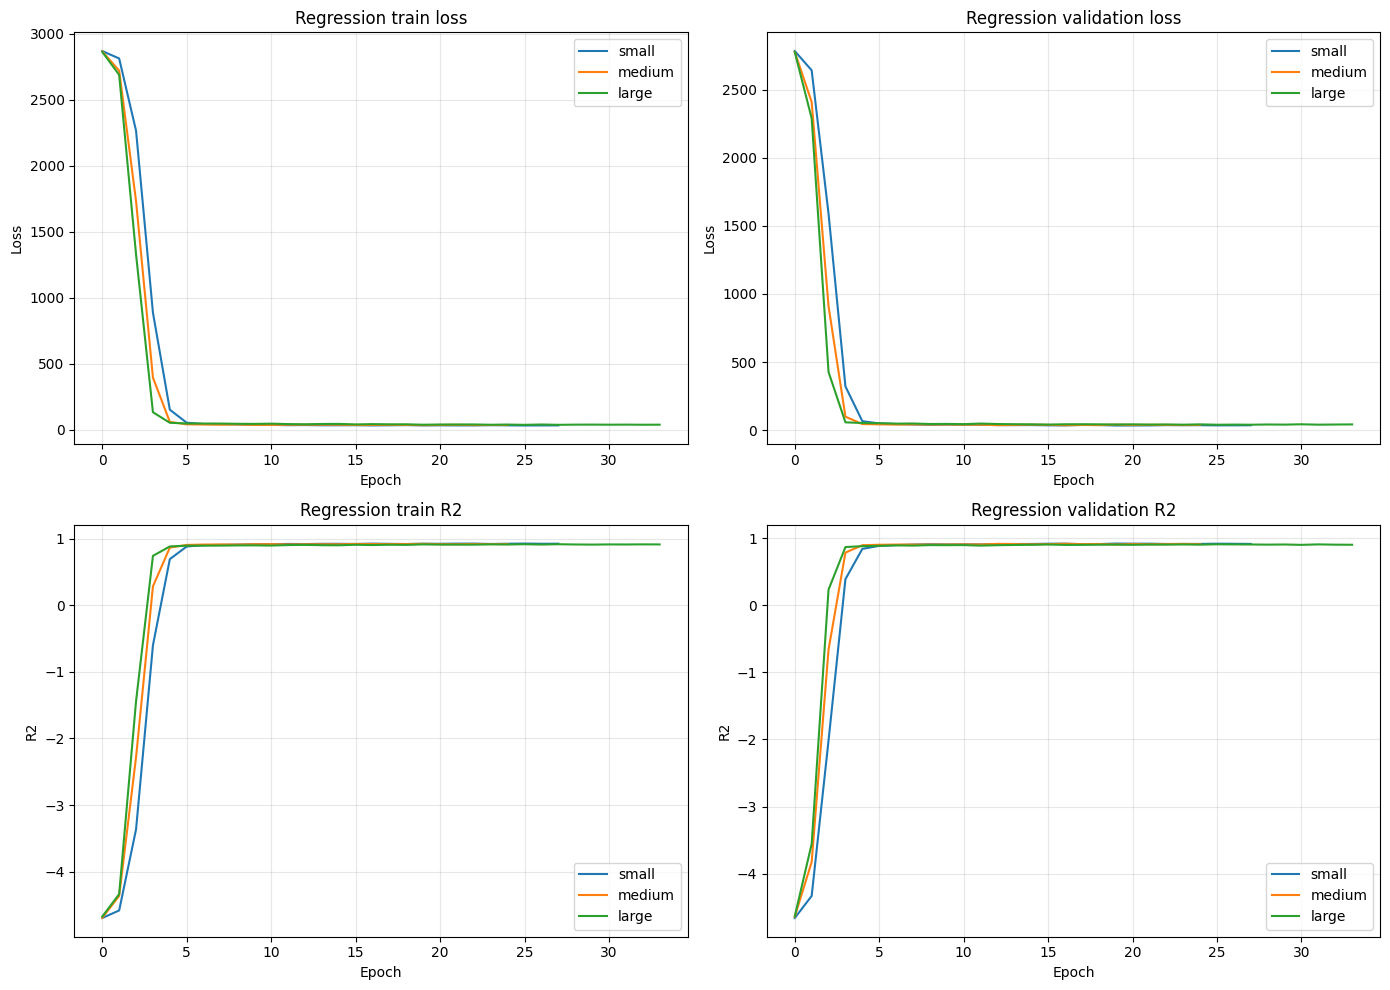

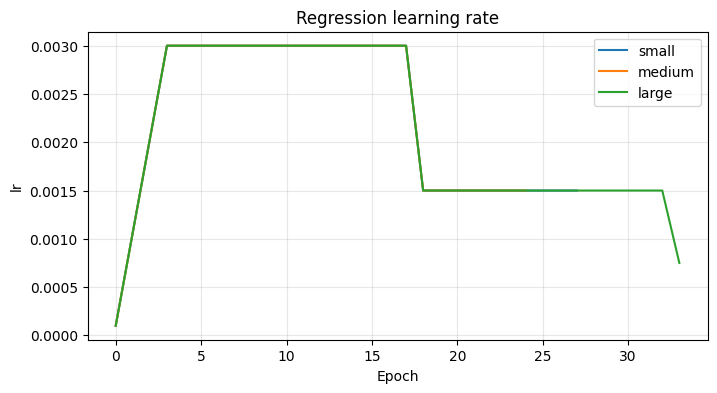

,best_epoch,best_val_loss,test_loss,test_r2
small,20.0,34.600281,30.863227,0.931495
medium,17.0,36.866393,34.895381,0.924368
large,26.0,40.214256,34.609825,0.923474


In [40]:

reg_histories = {
    "small": history_small,
    "medium": history_medium,
    "large": history_large,
}

plot_histories_comparison(reg_histories, metric_name="R2", title_prefix="Regression")
plot_lr_histories(reg_histories, title="Regression learning rate")

reg_results = {}
reg_predictions = {}

for name, model, history in [
    ("small", model_small, history_small),
    ("medium", model_medium, history_medium),
    ("large", model_large, history_large),
]:
    y_pred_test = model.forward(X_test)
    test_loss, test_r2 = evaluate_model(
        model,
        get_criterion("mse"),
        X_test,
        y_test,
        batch_size=128,
        metric_func=get_metric("r2"),
        mode="regression",
    )
    reg_results[name] = {
        "best_epoch": history["best_epoch"],
        "best_val_loss": history["best_val_loss"],
        "test_loss": test_loss,
        "test_r2": test_r2,
    }
    reg_predictions[name] = y_pred_test

reg_results_df = pd.DataFrame(reg_results).T.sort_values("test_r2", ascending=False)
reg_results_df


Best regression model on test: small


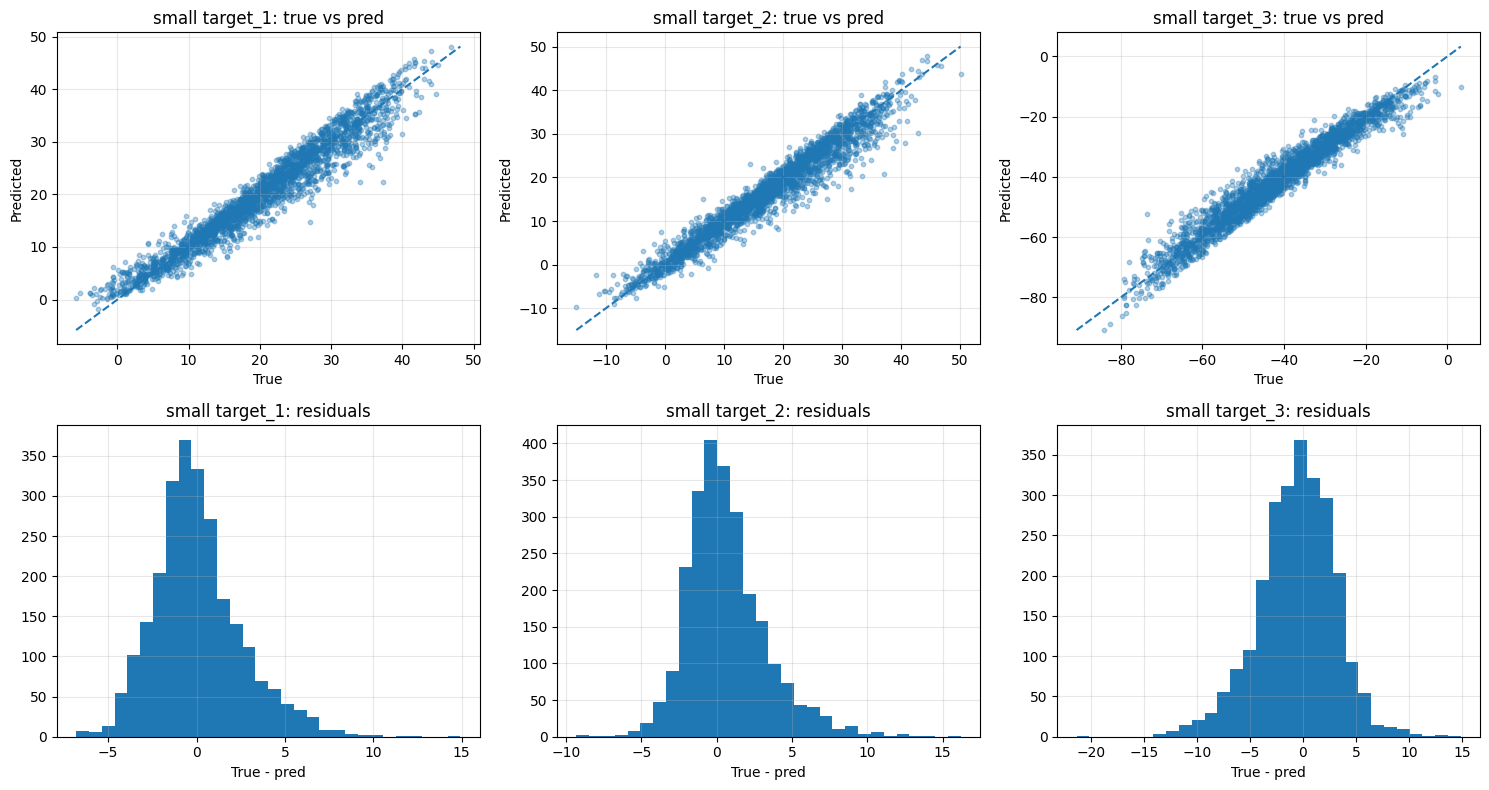

In [41]:
best_reg_name = reg_results_df["test_r2"].idxmax()
print(f"Best regression model on test: {best_reg_name}")

plot_regression_predictions(
    y_test,
    reg_predictions[best_reg_name],
    title_prefix=best_reg_name,
)

## 3. Модель мультиклассификации

### Модель для задачи мультиклассификации на MNIST. Использовать свёртки, макспулы, флэттэны, софтмаксы

In [42]:
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

train_val = MNIST(root="./data", train=True, download=True, transform=ToTensor())
test = MNIST(root="./data", train=False, download=True, transform=ToTensor())

### 3.2 Подготовка данных

In [43]:
X_all = train_val.data.numpy().astype(np.float32) / 255.0
y_all = train_val.targets.numpy()
X_test_cls = test.data.numpy().astype(np.float32) / 255.0
y_test_cls = test.targets.numpy()

X_all = X_all[:, None, :, :]
X_test_cls = X_test_cls[:, None, :, :]

X_train_cls, X_val_cls, y_train_cls, y_val_cls = train_test_split(
    X_all, y_all, test_size=0.15, random_state=42, stratify=y_all
)

# Для кастомных свёрток на numpy полный MNIST слишком медленный, поэтому берём подвыборки, чтобы ноутбук реально запускался
rng = np.random.default_rng(42)
train_idx = rng.choice(len(X_train_cls), size=min(6000, len(X_train_cls)), replace=False)
val_idx = rng.choice(len(X_val_cls), size=min(1000, len(X_val_cls)), replace=False)
test_idx = rng.choice(len(X_test_cls), size=min(1000, len(X_test_cls)), replace=False)

X_train_cls = X_train_cls[train_idx]
y_train_cls = y_train_cls[train_idx]
X_val_cls = X_val_cls[val_idx]
y_val_cls = y_val_cls[val_idx]
X_test_cls = X_test_cls[test_idx]
y_test_cls = y_test_cls[test_idx]

y_train_cls_oh = one_hot_encode(y_train_cls, 10)
y_val_cls_oh = one_hot_encode(y_val_cls, 10)
y_test_cls_oh = one_hot_encode(y_test_cls, 10)

print(X_train_cls.shape, X_val_cls.shape, X_test_cls.shape)


(6000, 1, 28, 28) (1000, 1, 28, 28) (1000, 1, 28, 28)


### 3.3 Модель для классификации

In [44]:
def create_classification_model():
    model = Sequential()
    model.add(Conv2d(in_channels=1, out_channels=8, kernel_size=5, padding=2))
    model.add(ReLU())
    model.add(MaxPool2d(kernel_size=2, stride=2, padding=0))
    model.add(Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1))
    model.add(ReLU())
    model.add(MaxPool2d(kernel_size=2, stride=2, padding=0))
    model.add(Flatten(start_dim=1))
    model.add(Linear(n_in=16 * 7 * 7, n_out=128))
    model.add(BatchNormalization())
    model.add(ChannelwiseScaling(128))
    model.add(ReLU())
    model.add(Dropout(0.25))
    model.add(Linear(n_in=128, n_out=10))
    model.add(SoftMax())
    return model


### 3.4 Создём модель

In [45]:
model_cls = create_classification_model()
criterion_cls = get_criterion("classnll")
optimizer_cls = get_optimizer("adam", model_cls, lr=1e-3, wd=1e-4)
scheduler_cls = WarmupStepLR(
    optimizer_cls,
    warmup_epochs=1,
    step_size=3,
    gamma=0.5,
    start_lr=1e-4
)

history_cls = train(
    model_cls,
    criterion_cls,
    optimizer_cls,
    scheduler_cls,
    X_train_cls,
    y_train_cls_oh,
    X_val_cls,
    y_val_cls_oh,
    epochs=6,
    batch_size=128,
    metric_func=get_metric("accuracy"),
    mode="classification",
    patience=2
)

Epoch 1/6 | lr=0.000100 | train_loss=2.2714 | val_loss=2.2380 | train_metric=0.2393 | val_metric=0.3950
Epoch 2/6 | lr=0.001000 | train_loss=1.9603 | val_loss=1.5561 | train_metric=0.7418 | val_metric=0.8680
Epoch 3/6 | lr=0.001000 | train_loss=1.0820 | val_loss=0.6788 | train_metric=0.9198 | val_metric=0.9390
Epoch 4/6 | lr=0.001000 | train_loss=0.4583 | val_loss=0.3336 | train_metric=0.9572 | val_metric=0.9630
Epoch 5/6 | lr=0.000500 | train_loss=0.2674 | val_loss=0.2584 | train_metric=0.9705 | val_metric=0.9600
Epoch 6/6 | lr=0.000500 | train_loss=0.2065 | val_loss=0.2197 | train_metric=0.9747 | val_metric=0.9680


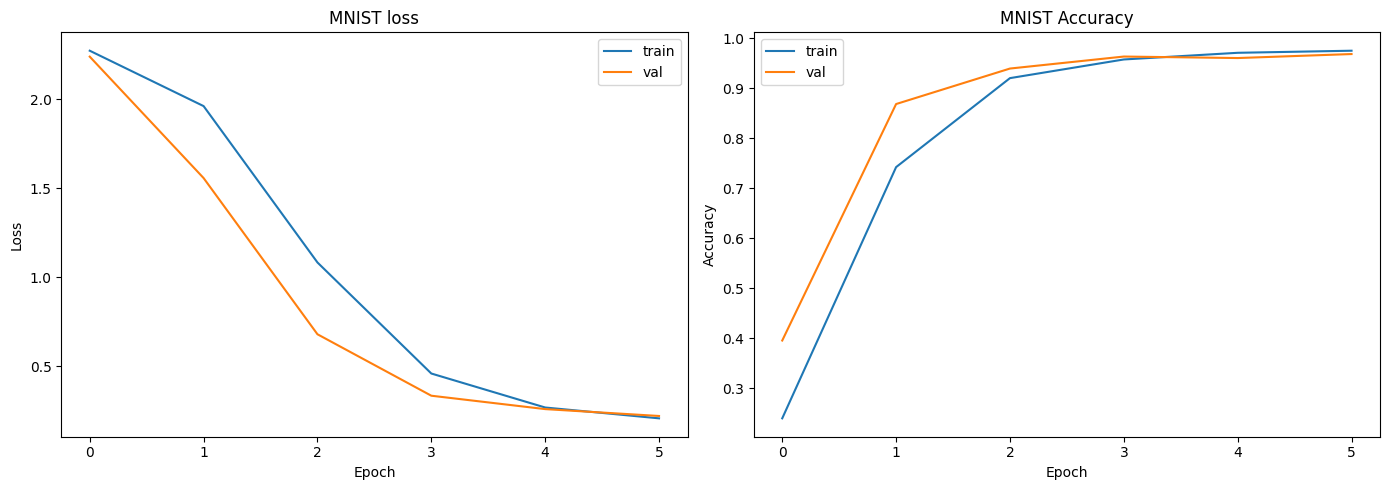

MNIST test loss: 0.2249
MNIST test accuracy: 0.9570


In [46]:
plot_history(history_cls, metric_name="Accuracy", title_prefix="MNIST")

test_loss_cls, test_acc_cls = evaluate_model(model_cls, criterion_cls, X_test_cls, y_test_cls_oh,
                                             batch_size=128, metric_func=get_metric("accuracy"), mode="classification")

print(f"MNIST test loss: {test_loss_cls:.4f}")
print(f"MNIST test accuracy: {test_acc_cls:.4f}")


## 4. Автоэнкодер

### Берём те же изображения MNIST. В автоэнкодере есть свёртки, полносвязные слои, dropout и batchnorm.


In [47]:
def create_autoencoder_model():
    model = Sequential()

    # Encoder
    model.add(Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1))
    model.add(ReLU())
    model.add(MaxPool2d(kernel_size=2, stride=2, padding=0))

    model.add(Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1))
    model.add(ReLU())
    model.add(MaxPool2d(kernel_size=2, stride=2, padding=0))

    model.add(Flatten(start_dim=1))
    model.add(Linear(16 * 7 * 7, 128))
    model.add(BatchNormalization())
    model.add(ChannelwiseScaling(128))
    model.add(ReLU())
    model.add(Dropout(0.2))

    model.add(Linear(128, 32))
    model.add(BatchNormalization())
    model.add(ChannelwiseScaling(32))
    model.add(ReLU())

    # Decoder
    model.add(Linear(32, 128))
    model.add(BatchNormalization())
    model.add(ChannelwiseScaling(128))
    model.add(ReLU())
    model.add(Dropout(0.2))

    model.add(Linear(128, 16 * 7 * 7))
    model.add(ReLU())
    model.add(Reshape(16, 7, 7))

    model.add(UpsampleNearest2d(scale_factor=2))
    model.add(Conv2d(in_channels=16, out_channels=8, kernel_size=3, padding=1))
    model.add(ReLU())

    model.add(UpsampleNearest2d(scale_factor=2))
    model.add(Conv2d(in_channels=8, out_channels=1, kernel_size=3, padding=1))

    return model


In [48]:
# Для автоэнкодера берём ещё меньшую выборку, чтобы обучение было быстрее
X_train_ae = X_train_cls[:2000]
X_val_ae = X_val_cls[:300]
X_test_ae = X_test_cls[:300]

model_ae = create_autoencoder_model()
criterion_ae = get_criterion("mse")
optimizer_ae = get_optimizer("adam", model_ae, lr=1e-3, wd=1e-4)
scheduler_ae = WarmupStepLR(
    optimizer_ae,
    warmup_epochs=1,
    step_size=3,
    gamma=0.5,
    start_lr=1e-4
)

history_ae = train(
    model_ae,
    criterion_ae,
    optimizer_ae,
    scheduler_ae,
    X_train_ae,
    X_train_ae,
    X_val_ae,
    X_val_ae,
    epochs=6,
    batch_size=128,
    metric_func=get_metric("mae"),
    mode="regression",
    patience=2
)

Epoch 1/6 | lr=0.000100 | train_loss=1431.0766 | val_loss=1115.6646 | train_metric=1.0643 | val_metric=0.9410
Epoch 2/6 | lr=0.001000 | train_loss=562.4633 | val_loss=287.9915 | train_metric=0.6604 | val_metric=0.4795
Epoch 3/6 | lr=0.001000 | train_loss=220.0025 | val_loss=174.4800 | train_metric=0.4152 | val_metric=0.3682
Epoch 4/6 | lr=0.001000 | train_loss=153.4847 | val_loss=136.6946 | train_metric=0.3443 | val_metric=0.3241
Epoch 5/6 | lr=0.000500 | train_loss=132.5390 | val_loss=125.8069 | train_metric=0.3187 | val_metric=0.3105
Epoch 6/6 | lr=0.000500 | train_loss=123.6750 | val_loss=118.0925 | train_metric=0.3070 | val_metric=0.2997


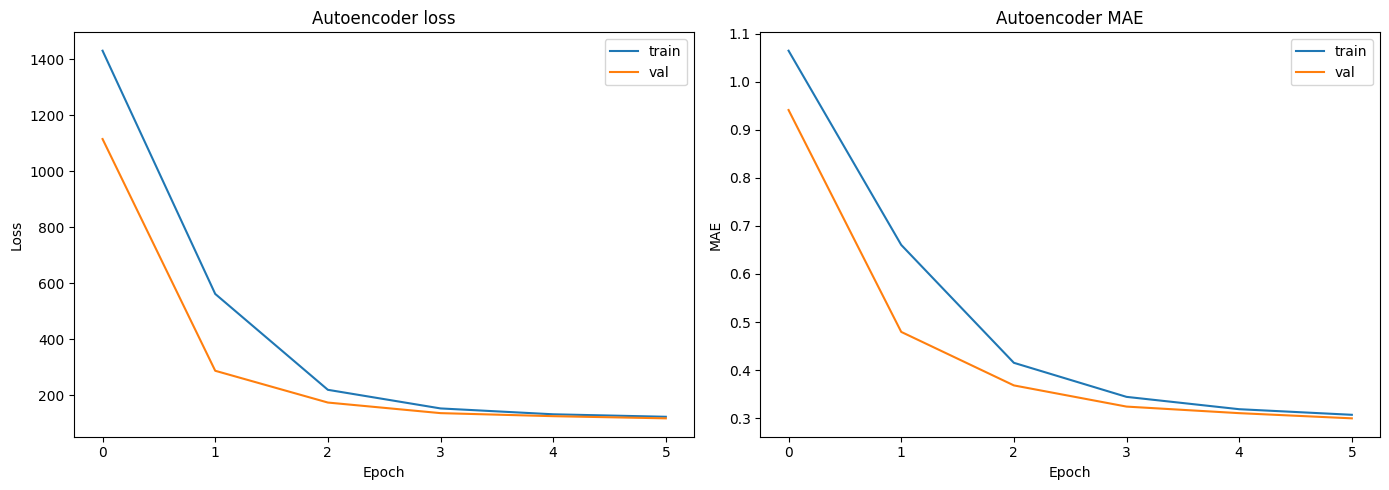

Autoencoder test loss: 119.4295
Autoencoder test MAE: 0.3013


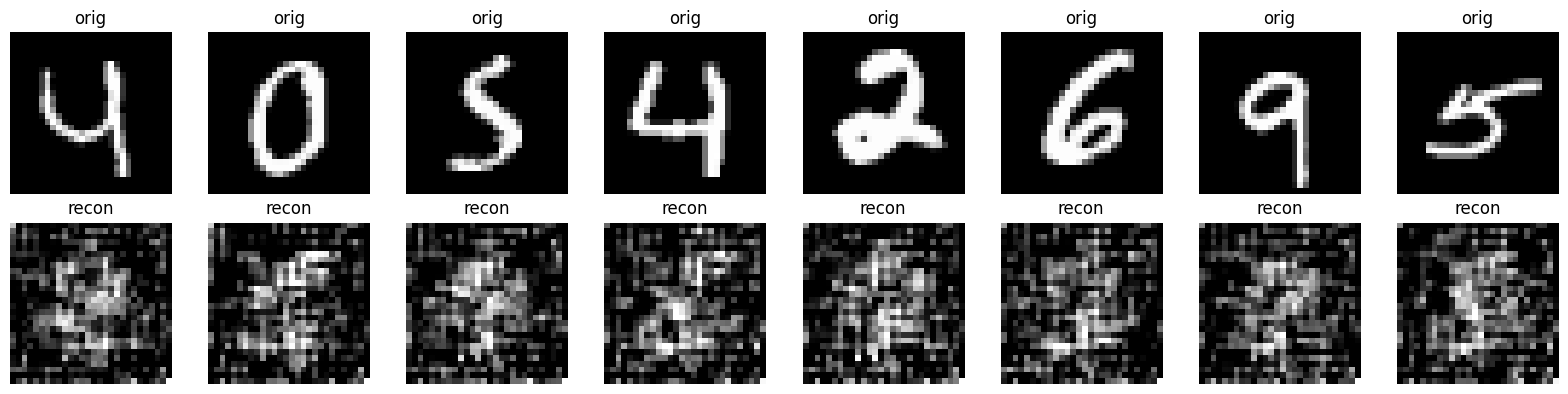

In [49]:
plot_history(history_ae, metric_name="MAE", title_prefix="Autoencoder")

ae_test_loss, ae_test_mae = evaluate_model(model_ae, criterion_ae, X_test_ae, X_test_ae,
                                           batch_size=128, metric_func=get_metric("mae"), mode="regression")

print(f"Autoencoder test loss: {ae_test_loss:.4f}")
print(f"Autoencoder test MAE: {ae_test_mae:.4f}")
show_reconstructions(model_ae, X_test_ae, n=8)